<a href="https://colab.research.google.com/github/stefkong1982/netology.ru/blob/Master/%D0%92%D0%B5%D1%81%D0%B0_%D0%AD%D0%BA%D1%81%D0%BF%D0%B5%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D1%82%D1%8B__%D0%A7%D0%B0%D1%81%D1%82%D1%8C_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Цель работы:**  
Разработать модель, способную предсказывать состав следующего заказа пользователя на основе анализа его истории покупок. Это позволит повысить персонализацию сервиса и улучшить пользовательский опыт, а также оптимизировать процессы формирования корзины и планирования закупок.


# Введение и постановка задачи

Современные сервисы доставки продуктов активно используют данные о покупках пользователей для улучшения качества и персонализации сервиса. Анализ истории заказов позволяет прогнозировать, какие категории товаров пользователь может захотеть приобрести в следующий раз.

Целью данного проекта является создание модели, способной по истории заказов прогнозировать состав будущего заказа пользователя. Такая рекомендация поможет клиенту сэкономить время на формировании корзины, избежать забытых позиций и повысить удобство планирования закупок.

Задача формализована как многоклассовая классификация: необходимо предсказать для каждой пары (пользователь, категория), будет ли категория включена в следующий заказ. Для оценки качества модели используется метрика F1-score, которая учитывает баланс между точностью и полнотой предсказаний.

Данные и постановка задачи основаны на открытом соревновании в области электронных продаж.


# Описание набора данных

В проекте используется история заказов 20 000 пользователей, разделённая на тренировочную и тестовую выборки по дате. Тестовая выборка содержит заказы после определённой даты отсечки.

Основной тренировочный файл содержит следующие данные:  
- **user_id** — уникальный идентификатор пользователя  
- **order_completed_at** — дата и время завершения заказа  
- **cart** — категория товара, входящего в заказ (уникальные категории)

Задача — для каждой пары (пользователь, категория), встречающейся в тестовой выборке, предсказать бинарный признак: будет ли категория присутствовать в следующем заказе пользователя.

Идентификаторы пар представлены в формате `"{user_id};{category_id}"`, что учитывается при обработке данных.

Данные подготовлены на основе истории заказов с учётом особенностей временного разделения выборок.


In [ ]:
# Подключение Google Drive для доступа к данным и сохранения результатов
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Создание структуры проекта
import os
from pathlib import Path
import pandas as pd
import numpy as np


# Основная папка проекта (как вы указали)
project_path = "/content/drive/MyDrive/Colab Notebooks/sm"

# Чек-лист папок и файлов
structure = [
    "data/raw",          # Исходные данные
    "data/processed",    # Очищенные данные
    "notebooks",         # Jupyter-тетради
    "src/models",        # Код моделей
    "src/utils",         # Утилиты
    "scripts",           # Скрипты обработки
]

# Создаём все директории
for folder in structure:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)


In [ ]:
# Функция для рекурсивного вывода структуры папок проекта
def print_tree(root, prefix=""):
    files = sorted(os.listdir(root))
    for i, name in enumerate(files):
        path = os.path.join(root, name)
        is_last = (i == len(files) - 1)
        branch = "└── " if is_last else "├── "
        print(prefix + branch + name + ("/" if os.path.isdir(path) else ""))
        if os.path.isdir(path):
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_tree(path, new_prefix)

print("\n=== Структура проекта (project_path) ===")
print_tree(project_path)


=== Структура проекта (project_path) ===
├── data/
│   ├── processed/
│   └── raw/
│       ├── sample_submission.csv
│       └── train.csv
├── notebooks/
├── plan/
├── scripts/
└── src/
    ├── models/
    └── utils/


In [ ]:
# Блок: Загрузка и первичный анализ train.csv
import pandas as pd
import os


train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/sm/data/raw/train.csv")

print("Структура и информация о train.csv:")
print(train.info())

Структура и информация о train.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123064 entries, 0 to 3123063
Data columns (total 3 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   user_id             int64 
 1   order_completed_at  object
 2   cart                int64 
dtypes: int64(2), object(1)
memory usage: 71.5+ MB
None


In [ ]:
print(f"Уникальных пользователей: {train['user_id'].nunique()}")

Уникальных пользователей: 20000


In [ ]:
train

,user_id,order_completed_at,cart
0,2,2015-03-22 09:25:46,399
1,2,2015-03-22 09:25:46,14
2,2,2015-03-22 09:25:46,198
3,2,2015-03-22 09:25:46,88
4,2,2015-03-22 09:25:46,157
...,...,...,...
3123059,12702,2020-09-03 23:45:45,441
3123060,12702,2020-09-03 23:45:45,92
3123061,12702,2020-09-03 23:45:45,431
3123062,12702,2020-09-03 23:45:45,24


In [ ]:
# Блок: Дополнительная статистика по train.csv

print("\nДополнительная статистика по train.csv:")

orders_per_user = train['user_id'].value_counts()
print("\nРаспределение количества заказов на пользователя:")
print(orders_per_user.describe())

print(f"\nУникальных категорий (корзин): {train['cart'].nunique()}")

train['order_completed_at'] = pd.to_datetime(train['order_completed_at'])
print("\nСтатистика по датам заказов:")
print(f"Период с {train['order_completed_at'].min()} по {train['order_completed_at'].max()}")



Дополнительная статистика по train.csv:

Распределение количества заказов на пользователя:
count    20000.000000
mean       156.153200
std        200.840781
min          3.000000
25%         48.000000
50%         88.000000
75%        181.000000
max       3508.000000
Name: count, dtype: float64

Уникальных категорий (корзин): 881

Статистика по датам заказов:
Период с 2015-03-22 09:25:46 по 2020-09-03 23:45:45


In [ ]:
# Блок: Загрузка и первичный анализ sample_submission.csv
sub = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/sm/data/raw/sample_submission.csv")

print("Структура и информация:")
print(sub.info())

Структура и информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790449 entries, 0 to 790448
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      790449 non-null  object
 1   target  790449 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 12.1+ MB
None


In [ ]:
sub

,id,target
0,0;133,0
1,0;5,1
2,0;10,0
3,0;396,1
4,0;14,0
...,...,...
790444,19998;26,0
790445,19998;31,0
790446,19998;29,1
790447,19998;798,1


In [ ]:
# Блок: Агрегация корзин и добавление порядкового номера заказа
#
# Назначение:
#   - Сгруппировать данные по пользователям и времени завершения заказа.
#   - Собрать список категорий товаров (корзину) в каждом заказе.
#   - Добавить порядковый номер заказа для каждого пользователя.
#
# Вход:
#   - DataFrame train с данными заказов.
# Выход:
#   - DataFrame orders_agg с агрегированными корзинами и порядковыми номерами.
#
train['order_completed_at'] = pd.to_datetime(train['order_completed_at'])

orders_agg = (
    train
    .groupby(['user_id', 'order_completed_at'])['cart']
    .apply(list)
    .reset_index()
    .rename(columns={'cart': 'cart_list'})
    .sort_values(['user_id', 'order_completed_at'])
)

orders_agg['order_number'] = (
    orders_agg
    .groupby('user_id')
    .cumcount() + 1
)

user_last_order = (
    orders_agg.groupby('user_id')['order_number'].max()
    .reset_index()
    .rename(columns={'order_number': 'max_order_number'})
)
orders_agg = orders_agg.merge(user_last_order, on='user_id', how='left')

full_orders = orders_agg.copy()

def unique_categories(df):
    return len(set(cat for cl in df['cart_list'] for cat in cl))

print("\nПолная выборка (full):")
print("  - Пользователей:", full_orders['user_id'].nunique())
print("  - Категорий:", unique_categories(full_orders))

print(full_orders.head(10).to_markdown(index=False))



Полная выборка (full):
  - Пользователей: 20000
  - Категорий: 881
|   user_id | order_completed_at   | cart_list                                                                                                         |   order_number |   max_order_number |
|----------:|:---------------------|:------------------------------------------------------------------------------------------------------------------|---------------:|-------------------:|
|         0 | 2020-07-19 09:59:17  | [20, 82, 441, 57, 14, 405, 430, 379]                                                                              |              1 |                  3 |
|         0 | 2020-08-24 08:55:32  | [133, 5, 26, 10, 382, 14, 22, 41, 25, 441, 411, 799, 432, 84, 83, 383, 409, 821, 405, 402, 57, 396, 379, 82, 157] |              2 |                  3 |
|         0 | 2020-09-02 07:38:25  | [803, 170, 84, 61, 440, 57, 55, 401, 398, 399, 169]                                                               |              3 

In [ ]:
# Блок: Добавление даты без времени и глобального номера заказа
#
# Назначение:
#   - Преобразовать дату и время заказа к дате без времени.
#   - Создать глобальный порядковый номер заказа по дате для всех пользователей.
#
# Вход:
#   - DataFrame full_orders с историей заказов.
# Выход:
#   - DataFrame full_orders с добавленными колонками order_date и global_order_number.
#
full_orders['order_date'] = full_orders['order_completed_at'].dt.date
full_orders = full_orders.sort_values('order_completed_at')

unique_dates = sorted(full_orders['order_date'].unique())
date_to_global_order_num = {date: idx + 1 for idx, date in enumerate(unique_dates)}
full_orders['global_order_number'] = full_orders['order_date'].map(date_to_global_order_num)


In [ ]:
print(full_orders.head().to_markdown(index=False))

|   user_id | order_completed_at   | cart_list                                                                |   order_number |   max_order_number | order_date   |   global_order_number |
|----------:|:---------------------|:-------------------------------------------------------------------------|---------------:|-------------------:|:-------------|----------------------:|
|         2 | 2015-03-22 09:25:46  | [399, 14, 198, 88, 157, 82, 134, 16, 409, 384, 808, 84, 23, 89, 57, 425] |              1 |                 15 | 2015-03-22   |                     1 |
|         3 | 2015-06-18 16:15:33  | [399]                                                                    |              1 |                  7 | 2015-06-18   |                     2 |
|         3 | 2015-07-04 14:05:22  | [399]                                                                    |              2 |                  7 | 2015-07-04   |                     3 |
|         4 | 2015-07-08 06:59:04  | [54, 55]          

In [ ]:
# Создаем колонку с годом и месяцем для каждого заказа
full_orders['year_month'] = full_orders['order_completed_at'].dt.to_period('M')

In [ ]:
print(full_orders.head(10).to_markdown(index=False))

|   user_id | order_completed_at   | cart_list                                                                |   order_number |   max_order_number | order_date   |   global_order_number | year_month   |
|----------:|:---------------------|:-------------------------------------------------------------------------|---------------:|-------------------:|:-------------|----------------------:|:-------------|
|         2 | 2015-03-22 09:25:46  | [399, 14, 198, 88, 157, 82, 134, 16, 409, 384, 808, 84, 23, 89, 57, 425] |              1 |                 15 | 2015-03-22   |                     1 | 2015-03      |
|         3 | 2015-06-18 16:15:33  | [399]                                                                    |              1 |                  7 | 2015-06-18   |                     2 | 2015-06      |
|         3 | 2015-07-04 14:05:22  | [399]                                                                    |              2 |                  7 | 2015-07-04   |                    

In [ ]:
# --- Индивидуальный порядковый номер месяца для каждого пользователя ---
# Получаем уникальные месяцы для каждого пользователя
unique_user_months = (
    full_orders[['user_id', 'year_month']]
    .drop_duplicates()
    .sort_values(['user_id', 'year_month'])
)

# Добавляем порядковый номер месяца для пользователя
unique_user_months['individual_month'] = unique_user_months.groupby('user_id').cumcount() + 1

# Объединяем обратно с исходным датафреймом
full_orders = full_orders.merge(unique_user_months, on=['user_id', 'year_month'], how='left')

In [ ]:
print(full_orders.head(10).to_markdown(index=False))

|   user_id | order_completed_at   | cart_list                                                                |   order_number |   max_order_number | order_date   |   global_order_number | year_month   |   individual_month |
|----------:|:---------------------|:-------------------------------------------------------------------------|---------------:|-------------------:|:-------------|----------------------:|:-------------|-------------------:|
|         2 | 2015-03-22 09:25:46  | [399, 14, 198, 88, 157, 82, 134, 16, 409, 384, 808, 84, 23, 89, 57, 425] |              1 |                 15 | 2015-03-22   |                     1 | 2015-03      |                  1 |
|         3 | 2015-06-18 16:15:33  | [399]                                                                    |              1 |                  7 | 2015-06-18   |                     2 | 2015-06      |                  1 |
|         3 | 2015-07-04 14:05:22  | [399]                                                          

In [ ]:
# --- Глобальный порядковый номер месяца по всему датафрейму ---
# Получаем уникальные глобальные месяцы по дате (без учета пользователя)
unique_global_months = (
    full_orders[['year_month']]
    .drop_duplicates()
    .sort_values('year_month')
    .reset_index(drop=True)
)
unique_global_months['global_month'] = unique_global_months.index + 1

# Объединяем обратно с основным датафреймом
full_orders = full_orders.merge(unique_global_months, on='year_month', how='left')


In [ ]:
print(full_orders.head(10).to_markdown(index=False))

|   user_id | order_completed_at   | cart_list                                                                |   order_number |   max_order_number | order_date   |   global_order_number | year_month   |   individual_month |   global_month |
|----------:|:---------------------|:-------------------------------------------------------------------------|---------------:|-------------------:|:-------------|----------------------:|:-------------|-------------------:|---------------:|
|         2 | 2015-03-22 09:25:46  | [399, 14, 198, 88, 157, 82, 134, 16, 409, 384, 808, 84, 23, 89, 57, 425] |              1 |                 15 | 2015-03-22   |                     1 | 2015-03      |                  1 |              1 |
|         3 | 2015-06-18 16:15:33  | [399]                                                                    |              1 |                  7 | 2015-06-18   |                     2 | 2015-06      |                  1 |              2 |
|         3 | 2015-07-04 14:05:2

In [ ]:
# Проверим результат для пользователя 1
user_1_orders = full_orders[full_orders['user_id'] == 1][
    ['individual_month', 'order_completed_at', 'cart_list', 'global_month']
]

print(user_1_orders.to_markdown(index=False))

In [ ]:
import numpy as np

# Фильтруем данные для пользователя 1
user_1_orders = full_orders[full_orders['user_id'] == 1]

# Группируем по individual_month и агрегируем корзины
user_1_summary = user_1_orders.groupby('individual_month').agg(
    order_count=('cart_list', 'count'),  # количество заказов в этом месяце
    unique_cats_in_month=('cart_list', lambda lists: len(set(cat for sublist in lists for cat in sublist))),  # уникальные категории за месяц
    avg_cart_size=('cart_list', lambda lists: np.mean([len(lst) for lst in lists])),  # средний размер корзины
    all_cats=('cart_list', lambda lists: set(cat for sublist in lists for cat in sublist))  # все категории за месяц
).reset_index()

# Создаем колонку для накопленной истории категорий
history_cats = set()
history_list = []
intersection_counts = []
overlap_cats_list = []
overlap_cats_counts = []
new_cats_list = []

for cats in user_1_summary['all_cats']:
    # Текущая история без текущих категорий
    history_list.append(history_cats.copy())

    # Пересечение текущих категорий с историей
    intersection = cats.intersection(history_cats)
    intersection_counts.append(len(intersection))

    # Категории, которые пересекаются с историей
    overlap_cats_list.append(intersection)
    overlap_cats_counts.append(len(intersection))

    # Новые категории — которые не были в истории
    new_cats = cats.difference(history_cats)
    new_cats_list.append(new_cats)

    # Обновляем историю — добавляем текущие категории
    history_cats.update(cats)

# Добавляем новые колонки в итоговый DataFrame
user_1_summary['history_cats'] = history_list
user_1_summary['history_overlap_count'] = intersection_counts
user_1_summary['overlap_cats'] = overlap_cats_list
user_1_summary['overlap_cats_count'] = overlap_cats_counts
user_1_summary['new_cats'] = new_cats_list

# Для удобства можно привести множества к строкам
user_1_summary['all_cats_str'] = user_1_summary['all_cats'].apply(lambda s: ', '.join(map(str, sorted(s))))
user_1_summary['history_cats_str'] = user_1_summary['history_cats'].apply(lambda s: ', '.join(map(str, sorted(s))))
user_1_summary['overlap_cats_str'] = user_1_summary['overlap_cats'].apply(lambda s: ', '.join(map(str, sorted(s))))
user_1_summary['new_cats_str'] = user_1_summary['new_cats'].apply(lambda s: ', '.join(map(str, sorted(s))))

# Выводим нужные колонки
print(user_1_summary[['individual_month', 'all_cats_str', 'history_cats_str', 'overlap_cats_str', 'overlap_cats_count', 'new_cats_str']].to_markdown(index=False))


In [ ]:
# Узнаем максимальный global_month в данных
max_global_month = full_orders['global_month'].max()

# Определяем последние два месяца
last_month = max_global_month
second_last_month = max_global_month - 1

# Фильтруем заказы за последний и предпоследний месяцы
orders_last_month = full_orders[full_orders['global_month'] == last_month]
orders_second_last_month = full_orders[full_orders['global_month'] == second_last_month]

# Считаем количество уникальных пользователей в каждом месяце
unique_users_last_month = orders_last_month['user_id'].nunique()
unique_users_second_last_month = orders_second_last_month['user_id'].nunique()

print(f"Уникальных пользователей в предпоследнем месяце (global_month={second_last_month}): {unique_users_second_last_month}")
print(f"Уникальных пользователей в последнем месяце (global_month={last_month}): {unique_users_last_month}")


In [ ]:
# Фильтруем заказы для предпоследнего и последнего глобального месяца
orders_last_month = full_orders[full_orders['global_month'] == last_month]
orders_second_last_month = full_orders[full_orders['global_month'] == second_last_month]

# Считаем количество уникальных дней в каждом глобальном месяце
unique_days_last_month = orders_last_month['order_completed_at'].dt.date.nunique()
unique_days_second_last_month = orders_second_last_month['order_completed_at'].dt.date.nunique()

print(f"Количество уникальных дней в предпоследнем месяце (global_month={second_last_month}): {unique_days_second_last_month}")
print(f"Количество уникальных дней в последнем месяце (global_month={last_month}): {unique_days_last_month}")


In [ ]:
# Фильтруем заказы за последний месяц
orders_last_month = full_orders[full_orders['global_month'] == last_month]

# Получаем уникальные даты заказов
unique_dates_last_month = orders_last_month['order_completed_at'].dt.date.unique()

print("Уникальные даты заказов в последнем месяце (global_month=60):")
for d in sorted(unique_dates_last_month):
    print(d)


In [ ]:
# Получаем уникальных пользователей из sub
# В sub в столбце 'id' формат "{user_id};{category_id}"
sub['user_id'] = sub['id'].apply(lambda x: int(x.split(';')[0]))
unique_sub_users = set(sub['user_id'].unique())
print(f"Уникальных пользователей в sub: {len(unique_sub_users)}")

# Получаем уникальных пользователей из предпоследнего global_month=59
users_second_last_month = set(full_orders[full_orders['global_month'] == 59]['user_id'].unique())
print(f"Уникальных пользователей в global_month=59: {len(users_second_last_month)}")

# Находим пересечение пользователей
intersection_users = unique_sub_users.intersection(users_second_last_month)
print(f"Количество пользователей, присутствующих и в sub, и в global_month=59: {len(intersection_users)}")


In [ ]:
# Сгруппируем full_orders по user_id и global_month, объединим корзины (cart_list) за месяц
full_orders_monthly = (
    full_orders
    .groupby(['user_id', 'global_month'])['cart_list']
    .apply(lambda lists: set(cat for sublist in lists for cat in sublist))
    .reset_index()
    .sort_values(['user_id', 'global_month'])
)

In [ ]:
full_orders_monthly

In [ ]:
# Создаем списки для накопления истории и новых колонок
history_cats = set()
history_list = []
overlap_cats_list = []
overlap_cats_counts = []
new_cats_list = []

prev_user_id = None
history_cats = set()

for idx, row in full_orders_monthly.iterrows():
    user = row['user_id']
    current_cats = row['cart_list']

    # Если новый пользователь, сбрасываем историю
    if user != prev_user_id:
        history_cats = set()
        prev_user_id = user

    # Добавляем историю до текущего месяца
    history_list.append(history_cats.copy())

    # Пересечение с историей
    intersection = current_cats.intersection(history_cats)
    overlap_cats_list.append(intersection)
    overlap_cats_counts.append(len(intersection))

    # Новые категории в этом месяце
    new_cats = current_cats.difference(history_cats)
    new_cats_list.append(new_cats)

    # Обновляем историю
    history_cats.update(current_cats)

In [ ]:
# Добавляем новые столбцы с множествами
full_orders_monthly['history_cats'] = history_list
full_orders_monthly['overlap_cats'] = overlap_cats_list
full_orders_monthly['overlap_cats_count'] = overlap_cats_counts
full_orders_monthly['new_cats'] = new_cats_list

In [ ]:
full_orders_monthly

In [ ]:
# 3. Распределение количества пересечений с историей (overlap_cats_count)

print(full_orders_monthly['overlap_cats_count'].describe())

In [ ]:
# 5. Scatter plot: количество месяцев пользователя vs средний размер корзины
user_stats = full_orders_monthly.groupby('user_id').agg({
    'global_month': 'nunique',
    'overlap_cats_count': 'mean'
}).rename(columns={'global_month': 'months_active',
                   'overlap_cats_count': 'avg_overlap_cats'})

print(user_stats.describe())

In [ ]:
# Удаляем записи с global_month == 60
filtered_orders = full_orders_monthly[full_orders_monthly['global_month'] != 60]

In [ ]:
filtered_orders

In [ ]:
# Находим максимальный global_month после удаления 60
max_global_month = filtered_orders['global_month'].max()

In [ ]:
max_global_month

59

In [ ]:
# Определяем последние 4 месяца
last_4_months = list(range(max_global_month - 3, max_global_month + 1))

In [ ]:
# Выбираем записи только за последние 4 месяца
last_4_months_data = filtered_orders[filtered_orders['global_month'].isin(last_4_months)]

In [ ]:
last_4_months_data

,user_id,global_month,cart_list,history_cats,overlap_cats,overlap_cats_count,new_cats
0,0,58,"{14, 430, 82, 20, 405, 441, 379, 57}",{},{},0,"{14, 430, 82, 20, 405, 441, 379, 57}"
1,0,59,"{5, 133, 10, 396, 14, 402, 405, 22, 409, 25, 2...","{14, 430, 82, 20, 405, 441, 379, 57}","{14, 82, 405, 441, 379, 57}",6,"{5, 133, 10, 396, 402, 22, 409, 26, 411, 25, 1..."
8,1,56,"{169, 170, 171, 14, 55, 798}","{421, 231, 169, 204, 812, 14, 82, 19, 23, 86, ...","{169, 798, 14, 55}",4,"{170, 171}"
9,1,58,"{803, 169, 302, 14, 307, 149, 54, 55, 88}","{421, 231, 169, 170, 171, 204, 812, 14, 82, 19...","{88, 169, 14, 55}",4,"{803, 302, 307, 149, 54}"
17,2,57,"{160, 100, 15, 87, 23, 382, 383}","{0, 5, 9, 14, 15, 16, 17, 19, 22, 23, 24, 25, ...","{160, 100, 15, 87, 23, 382, 383}",7,{}
...,...,...,...,...,...,...,...
93846,19995,59,"{0, 67, 712, 393, 398, 14, 84, 57, 31}",{},{},0,"{0, 67, 712, 393, 398, 14, 84, 57, 31}"
93847,19996,59,"{804, 231, 393, 396, 812, 431, 82, 84, 404, 22...",{},{},0,"{804, 231, 393, 396, 812, 431, 82, 84, 404, 22..."
93849,19997,59,"{0, 131, 135, 398, 14, 17, 23, 160, 420, 430, ...",{},{},0,"{0, 131, 135, 398, 14, 17, 23, 160, 420, 430, ..."
93850,19998,59,"{420, 6, 398, 57, 26, 31, 29, 415}",{},{},0,"{420, 6, 398, 57, 26, 31, 29, 415}"


In [ ]:
# Находим пользователей, активных во всех последних 4 месяцах
active_users = (
    last_4_months_data
    .groupby('user_id')['global_month']
    .nunique()
    .reset_index()
    .query('global_month == 4')['user_id']
    .tolist()
)

In [ ]:
# Оставляем только таких пользователей и последние 4 месяца
filtered_full_orders_monthly = filtered_orders[
    (filtered_orders['user_id'].isin(active_users)) &
    (filtered_orders['global_month'].isin(last_4_months))
].copy()

In [ ]:
filtered_full_orders_monthly

,user_id,global_month,cart_list,history_cats,overlap_cats,overlap_cats_count,new_cats
168,14,56,"{807, 808, 41, 394, 169, 812, 19, 85, 440, 446}","{0, 5, 6, 9, 10, 14, 15, 16, 17, 19, 20, 21, 2...","{807, 808, 41, 394, 169, 812, 19, 85, 440, 446}",10,{}
169,14,57,"{804, 169, 394, 55, 446}","{0, 5, 6, 9, 10, 14, 15, 16, 17, 19, 20, 21, 2...","{804, 169, 394, 55, 446}",5,{}
170,14,58,"{0, 417, 256, 67, 422, 169, 170, 430, 19, 408,...","{0, 5, 6, 9, 10, 14, 15, 16, 17, 19, 20, 21, 2...","{0, 417, 256, 67, 422, 169, 170, 430, 19, 408,...",11,{}
171,14,59,"{5, 394, 402, 19, 22, 798, 802, 807, 169, 170,...","{0, 5, 6, 9, 10, 14, 15, 16, 17, 19, 20, 21, 2...","{5, 394, 402, 19, 22, 798, 807, 169, 170, 41, ...",27,"{209, 802, 253}"
196,16,56,"{384, 9, 14, 402, 19, 29, 419, 420, 41, 42, 16...","{0, 5, 6, 9, 10, 522, 525, 14, 15, 16, 17, 19,...","{384, 419, 420, 9, 41, 42, 169, 14, 430, 432, ...",17,"{754, 196, 29}"
...,...,...,...,...,...,...,...
84035,15620,59,"{0, 382, 387, 395, 430, 14, 17, 19, 22, 23, 24...","{9, 11, 13, 14, 16, 17, 19, 20, 23, 26, 27, 29...","{395, 430, 14, 17, 19, 23, 409, 61, 382, 57}",10,"{0, 387, 22, 24, 30, 383}"
84040,15622,56,"{0, 385, 5, 9, 11, 395, 23, 25, 29, 157, 425, ...",{},{},0,"{0, 385, 5, 9, 11, 395, 23, 88, 25, 29, 157, 5..."
84041,15622,57,"{0, 5, 9, 10, 12, 13, 14, 15, 16, 19, 20, 21, ...","{0, 385, 5, 9, 11, 395, 23, 88, 25, 29, 157, 5...","{0, 376, 5, 9, 425, 395, 441, 430, 61, 23, 88,...",15,"{10, 12, 13, 14, 15, 16, 271, 19, 20, 21, 22, ..."
84042,15622,58,"{384, 104, 41, 409, 43, 11, 19, 84, 406, 440, ...","{0, 5, 9, 10, 11, 12, 13, 14, 15, 16, 271, 19,...","{41, 11, 43, 19, 84, 799, 440, 409, 382, 57}",10,"{384, 104, 406}"


In [ ]:
print(f"Количество пользователей после фильтрации: {len(active_users)}")
print(f"Размер отфильтрованного датафрейма: {filtered_full_orders_monthly.shape}")

Количество пользователей после фильтрации: 4634
Размер отфильтрованного датафрейма: (18536, 7)


In [ ]:
print("Распределение количества пересечений с историей:")
print(filtered_full_orders_monthly['overlap_cats_count'].describe())

Распределение количества пересечений с историей:
count    18536.000000
mean        20.985596
std         15.014021
min          0.000000
25%         10.000000
50%         19.000000
75%         30.000000
max        113.000000
Name: overlap_cats_count, dtype: float64


In [ ]:
# Группируем по пользователям и считаем std для overlap_cats_count
user_overlap_std = filtered_full_orders_monthly.groupby('user_id')['overlap_cats_count'].std().reset_index()

In [ ]:
user_overlap_std

,user_id,overlap_cats_count
0,14,9.535023
1,16,15.413738
2,21,14.930394
3,35,8.679478
4,37,5.477226
...,...,...
4629,15609,4.123106
4630,15611,4.932883
4631,15615,16.832508
4632,15620,13.047988


In [ ]:
# Определяем порог стабильности — медиану std
std_threshold = user_overlap_std['overlap_cats_count'].median()


In [ ]:
std_threshold

6.515986323710905

In [ ]:
q25 = user_overlap_std['overlap_cats_count'].quantile(0.25)
q75 = user_overlap_std['overlap_cats_count'].quantile(0.75)
mean_val = user_overlap_std['overlap_cats_count'].mean()
std_val = user_overlap_std['overlap_cats_count'].std()

print(f"25-й перцентиль: {q25:.2f}")
print(f"Медиана (50-й перцентиль): {std_threshold:.2f}")
print(f"75-й перцентиль: {q75:.2f}")
print(f"Среднее: {mean_val:.2f}, Стандартное отклонение: {std_val:.2f}")


25-й перцентиль: 4.12
Медиана (50-й перцентиль): 6.52
75-й перцентиль: 9.64
Среднее: 7.40, Стандартное отклонение: 4.47


In [ ]:
# Отбираем пользователей с дисперсией ниже или равной медиане
stable_users = user_overlap_std[user_overlap_std['overlap_cats_count'] <= std_threshold]['user_id']

In [ ]:
print(f"Всего пользователей: {user_overlap_std.shape[0]}")
print(f"Пользователей с низкой дисперсией overlap_cats_count: {len(stable_users)}")

Всего пользователей: 4634
Пользователей с низкой дисперсией overlap_cats_count: 2317


In [ ]:
# Фильтруем исходный датафрейм по стабильным пользователям
stable_behavior_data = filtered_full_orders_monthly[filtered_full_orders_monthly['user_id'].isin(stable_users)].copy()

print(f"Размер датафрейма с пользователями с низкой дисперсией: {stable_behavior_data.shape}")

Размер датафрейма с пользователями с низкой дисперсией: (9268, 7)


In [ ]:
stable_behavior_data

,user_id,global_month,cart_list,history_cats,overlap_cats,overlap_cats_count,new_cats
365,37,56,"{0, 5, 11, 396, 14, 398, 16, 15, 402, 403, 19,...","{384, 385, 386, 388, 5, 398, 15, 16, 17, 14, 1...","{5, 398, 14, 16, 15, 402, 403, 19, 22, 24, 409...",24,"{0, 67, 420, 11, 396, 431, 405, 85, 86, 440, 2..."
366,37,57,"{398, 14, 15, 17, 16, 19, 21, 22, 409, 25, 411...","{0, 384, 385, 386, 388, 5, 11, 396, 14, 15, 16...","{398, 15, 16, 17, 14, 19, 22, 409, 25, 421, 41...",20,"{432, 379, 21, 55, 376, 411}"
367,37,58,"{0, 392, 394, 398, 15, 16, 14, 402, 19, 22, 23...","{0, 5, 11, 14, 15, 16, 17, 274, 19, 18, 21, 22...","{0, 420, 425, 14, 398, 16, 15, 402, 19, 431, 8...",17,"{392, 394, 64, 408}"
368,37,59,"{100, 388, 650, 430, 14, 398, 432, 402, 19, 40...","{0, 5, 11, 14, 15, 16, 17, 274, 19, 18, 21, 22...","{388, 100, 398, 430, 14, 432, 402, 19, 409, 41...",11,"{650, 407}"
701,52,56,"{5, 396, 402, 406, 23, 409, 798, 420, 41, 302,...","{0, 1, 5, 6, 9, 11, 14, 15, 16, 17, 18, 19, 20...","{5, 396, 402, 406, 23, 409, 798, 420, 41, 302,...",19,{303}
...,...,...,...,...,...,...,...
84002,15609,59,"{64, 420, 808, 425, 42, 441, 812, 715, 432, 21...","{64, 388, 391, 392, 395, 715, 14, 16, 17, 403,...","{64, 420, 808, 425, 715, 432, 57, 61}",8,"{441, 42, 812, 21}"
84005,15611,56,"{9, 14, 17, 86, 409, 61, 31}",{},{},0,"{17, 86, 9, 409, 61, 14, 31}"
84006,15611,57,"{9, 398, 15, 16, 17, 14, 19, 22, 23, 409, 412,...","{17, 86, 9, 409, 61, 14, 31}","{9, 14, 17, 86, 409, 61, 31}",7,"{89, 77, 398, 15, 16, 430, 431, 19, 432, 55, 2..."
84007,15611,58,"{384, 89, 803, 71, 43, 14, 398, 16, 84, 437, 5...","{9, 77, 14, 398, 15, 17, 16, 19, 84, 86, 22, 2...","{398, 14, 16, 84, 89, 61, 57}",7,"{384, 803, 71, 43, 437}"


In [ ]:
print("Распределение количества пересечений с историей:")
print(stable_behavior_data['overlap_cats_count'].describe())

Распределение количества пересечений с историей:
count    9268.000000
mean       17.300173
std        13.066980
min         0.000000
25%         8.000000
50%        14.000000
75%        24.000000
max        89.000000
Name: overlap_cats_count, dtype: float64


In [ ]:
# Функция для вывода истории пользователя (месяц и cart_list)
def print_user_order_history(user_id, df, title):
    user_data = df[df['user_id'] == user_id].sort_values('global_month')
    print(f"\nИстория заказов {title} (user_id={user_id}):")
    for _, row in user_data.iterrows():
        month = row['global_month']
        cart = sorted(row['cart_list'])
        print(f"  Месяц {month}: корзина категорий {cart}")

# Выбираем стабильного и нестабильного пользователя (как в предыдущем коде)
stable_user_id = stable_users.iloc[0]
unstable_user_id = user_overlap_std[user_overlap_std['overlap_cats_count'] > std_threshold]['user_id'].iloc[0]

# Выводим истории
print_user_order_history(stable_user_id, filtered_full_orders_monthly, "стабильного пользователя")
print_user_order_history(unstable_user_id, filtered_full_orders_monthly, "нестабильного пользователя")




История заказов стабильного пользователя (user_id=37):
  Месяц 56: корзина категорий [0, 5, 11, 14, 15, 16, 19, 22, 24, 25, 26, 27, 31, 41, 42, 43, 57, 61, 67, 82, 84, 85, 86, 100, 179, 380, 381, 382, 396, 398, 402, 403, 405, 409, 420, 430, 431, 440]
  Месяц 57: корзина категорий [14, 15, 16, 17, 19, 21, 22, 25, 41, 55, 57, 61, 67, 82, 87, 100, 376, 379, 380, 383, 398, 409, 411, 421, 431, 432]
  Месяц 58: корзина категорий [0, 14, 15, 16, 19, 22, 23, 24, 57, 64, 82, 88, 380, 392, 394, 398, 402, 408, 420, 425, 431]
  Месяц 59: корзина категорий [14, 19, 57, 100, 388, 398, 402, 407, 409, 411, 430, 432, 650]

История заказов нестабильного пользователя (user_id=14):
  Месяц 56: корзина категорий [19, 41, 85, 169, 394, 440, 446, 807, 808, 812]
  Месяц 57: корзина категорий [55, 169, 394, 446, 804]
  Месяц 58: корзина категорий [0, 19, 67, 169, 170, 256, 382, 408, 417, 422, 430]
  Месяц 59: корзина категорий [5, 19, 22, 41, 55, 57, 61, 67, 82, 84, 85, 87, 104, 169, 170, 198, 209, 253, 382, 

In [ ]:
# Извлечь все категории из множества cart_list для всех строк и объединить в один набор
unique_categories = set(cat for cats_set in stable_behavior_data['cart_list'] for cat in cats_set)

print(f"Количество уникальных категорий в stable_behavior_data: {len(unique_categories)}")


Количество уникальных категорий в stable_behavior_data: 658


In [ ]:
import pandas as pd
from collections import Counter

# --- 1. Топ-30 категорий по всей истории всех пользователей (full_orders) ---
all_categories_full = [cat for cart_list in full_orders['cart_list'] for cat in cart_list]
cat_counts_full = Counter(all_categories_full)
top30_full = cat_counts_full.most_common(30)
top30_full_cats = [cat for cat, count in top30_full]

# --- 2. Топ-30 категорий по истории стабильных пользователей (stable_behavior_data) ---
stable_categories = [cat for cart_list in stable_behavior_data['cart_list'] for cat in cart_list]
cat_counts_stable = Counter(stable_categories)
top30_stable = cat_counts_stable.most_common(30)
top30_stable_cats = [cat for cat, count in top30_stable]

# --- 3. Пересечение ---
intersection_cats = list(set(top30_full_cats) & set(top30_stable_cats))

# --- 4. Вывод результатов в компактном виде ---
print("**Топ-30 категорий по всем пользователям (отсортирован по рангу):**")
print(f"`{top30_full_cats}`")
print()
print("**Топ-30 категорий по стабильным пользователям (отсортирован по рангу):**")
print(f"`{top30_stable_cats}`")
print()
print("**Пересечение (категории, вошедшие в Топ-30 обоих групп):**")
print(f"`{sorted(intersection_cats)}`")
print(f"(Количество: {len(intersection_cats)})")
print()
print("**Категории только в Топ-30 всех пользователей:**")
only_in_full = list(set(top30_full_cats) - set(top30_stable_cats))
print(f"`{sorted(only_in_full)}`")
print()
print("**Категории только в Топ-30 стабильных пользователей:**")
only_in_stable = list(set(top30_stable_cats) - set(top30_full_cats))
print(f"`{sorted(only_in_stable)}`")


**Топ-30 категорий по всем пользователям (отсортирован по рангу):**
`[57, 14, 61, 398, 23, 84, 22, 409, 17, 402, 55, 383, 420, 382, 19, 430, 41, 169, 425, 16, 9, 88, 384, 42, 395, 5, 432, 54, 89, 29]`

**Топ-30 категорий по стабильным пользователям (отсортирован по рангу):**
`[57, 14, 61, 398, 23, 22, 84, 17, 420, 383, 382, 409, 169, 19, 55, 402, 41, 430, 88, 425, 5, 42, 384, 16, 388, 89, 9, 432, 395, 54]`

**Пересечение (категории, вошедшие в Топ-30 обоих групп):**
`[5, 9, 14, 16, 17, 19, 22, 23, 41, 42, 54, 55, 57, 61, 84, 88, 89, 169, 382, 383, 384, 395, 398, 402, 409, 420, 425, 430, 432]`
(Количество: 29)

**Категории только в Топ-30 всех пользователей:**
`[29]`

**Категории только в Топ-30 стабильных пользователей:**
`[388]`


Вот интерпретация полученных результатов:

1.  **Высокая степень совпадения:** 29 из 30 наиболее популярных категорий у всех пользователей также находятся в Топ-30 у стабильных пользователей. Это говорит о том, что в целом предпочтения стабильных пользователей сильно коррелируют с общими трендами.
2.  **Различия в хвосте рейтинга:** Основное различие заключается в 30-й позиции рейтинга:
    *   Все пользователи: **Категория 29** (27659 покупок).
    *   Стабильные пользователи: **Категория 388** (2359 покупок).
    Это указывает на то, что категория 29 популярна в общей массе, но, возможно, менее привлекательна или редко покупается именно стабильными пользователями. И наоборот, категория 388, хотя и не входит в абсолютный топ-30 по количеству заказов, достаточно часто встречается у стабильной аудитории, чтобы войти в их персональный Топ-30.
3.  **Стабильность поведения:** То, что пересечение составляет 29 из 30 позиций, подтверждает, что стабильные пользователи в целом следуют общим трендам потребления. Их поведение предсказуемо и согласуется с популярными категориями.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Подготовка данных ---
# 1. Исключим неполный месяц 60
full_orders_filtered = full_orders[full_orders['global_month'] != 60].copy()
print(f"Анализируем данные за месяцы: {sorted(full_orders_filtered['global_month'].unique())}")
print(f"Последний полный месяц для анализа 'свежести': {full_orders_filtered['global_month'].max()}")

Анализируем данные за месяцы: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59)]
Последний полный месяц для анализа 'свежести': 59


In [ ]:
# 2. Подсчет количества покупок каждой категории в каждом месяце
monthly_category_counts = defaultdict(int)

for index, row in full_orders_filtered.iterrows():
    global_month = row['global_month']
    cart_list = row['cart_list']
    for category in cart_list:
        monthly_category_counts[(global_month, category)] += 1

In [ ]:
# 3. Преобразование в DataFrame
data_for_analysis = [
    {'global_month': gm, 'category': cat, 'count': cnt}
    for (gm, cat), cnt in monthly_category_counts.items()
]
df_monthly_counts = pd.DataFrame(data_for_analysis)

In [ ]:
df_monthly_counts

,global_month,category,count
0,1,399,1
1,1,14,1
2,1,198,1
3,1,88,1
4,1,157,1
...,...,...,...
15168,59,521,1
15169,59,567,1
15170,59,570,1
15171,59,789,1


In [ ]:
# --- Анализ для категорий 29 и 388 ---
categories_of_interest = [29, 388]
df_filtered = df_monthly_counts[df_monthly_counts['category'].isin(categories_of_interest)].copy()

In [ ]:
df_filtered

,global_month,category,count
27,3,29,1
116,10,388,1
163,11,29,1
263,12,388,1
343,13,388,3
...,...,...,...
13134,57,388,6039
13787,58,29,4199
13894,58,388,3909
14475,59,388,4026


In [ ]:
# 4. Расчет взвешенных значений
df_filtered['weighted_count'] = df_filtered['count'] * df_filtered['global_month']

In [ ]:
df_filtered

,global_month,category,count,weighted_count
27,3,29,1,3
116,10,388,1,10
163,11,29,1,11
263,12,388,1,12
343,13,388,3,39
...,...,...,...,...
13134,57,388,6039,344223
13787,58,29,4199,243542
13894,58,388,3909,226722
14475,59,388,4026,237534


In [ ]:
# 5. Определение "свежести" как взвешенного значения в последнем месяце (59)
last_full_month = full_orders_filtered['global_month'].max()
print(f"\nОпределяем 'свежесть' по месяцу: {last_full_month}")

df_last_month = df_filtered[df_filtered['global_month'] == last_full_month]

freshness_scores = df_last_month.groupby('category')['weighted_count'].sum().reindex(categories_of_interest, fill_value=0)


Определяем 'свежесть' по месяцу: 59


In [ ]:
df_last_month

,global_month,category,count,weighted_count
14475,59,388,4026,237534
14508,59,29,3872,228448


In [ ]:
# 6. Общее количество покупок (для сравнения)
total_counts = df_filtered.groupby('category')['count'].sum().reindex(categories_of_interest, fill_value=0)

# --- Вывод результатов ---
print("\n" + "="*50)
print("=== Сравнение 'свежести' категорий 29 и 388 ===")
comparison_df = pd.DataFrame({
    'Категория': categories_of_interest,
    'Общие продажи': total_counts.values,
    f'Свежесть (взвеш. сумма в мес. {last_full_month})': freshness_scores.values
})
print(comparison_df.to_string(index=False))

# --- Подробные данные по месяцам (в строку) ---
print("\n" + "="*50)
print("--- Подробные данные по месяцам ---")
for cat in categories_of_interest:
    df_cat = df_filtered[df_filtered['category'] == cat].sort_values('global_month')
    months_str = ", ".join([f"М{row['global_month']}:{row['count']}(взв.{row['weighted_count']})" for _, row in df_cat.iterrows()])
    print(f"Категория {cat}: {months_str}")


=== Сравнение 'свежести' категорий 29 и 388 ===
 Категория  Общие продажи  Свежесть (взвеш. сумма в мес. 59)
        29          27244                             228448
       388          26890                             237534

--- Подробные данные по месяцам ---
Категория 29: М3:1(взв.3), М11:1(взв.11), М13:2(взв.26), М14:4(взв.56), М15:2(взв.30), М16:2(взв.32), М17:5(взв.85), М18:4(взв.72), М19:7(взв.133), М20:4(взв.80), М21:2(взв.42), М22:6(взв.132), М23:13(взв.299), М24:6(взв.144), М25:11(взв.275), М26:8(взв.208), М27:10(взв.270), М28:6(взв.168), М29:10(взв.290), М30:5(взв.150), М31:13(взв.403), М32:5(взв.160), М33:8(взв.264), М34:15(взв.510), М35:17(взв.595), М36:20(взв.720), М37:24(взв.888), М38:24(взв.912), М39:31(взв.1209), М40:26(взв.1040), М41:36(взв.1476), М42:67(взв.2814), М43:90(взв.3870), М44:117(взв.5148), М45:147(взв.6615), М46:205(взв.9430), М47:265(взв.12455), М48:454(взв.21792), М49:1083(взв.53067), М50:1457(взв.72850), М51:1319(взв.67269), М52:1228(взв.63856), 

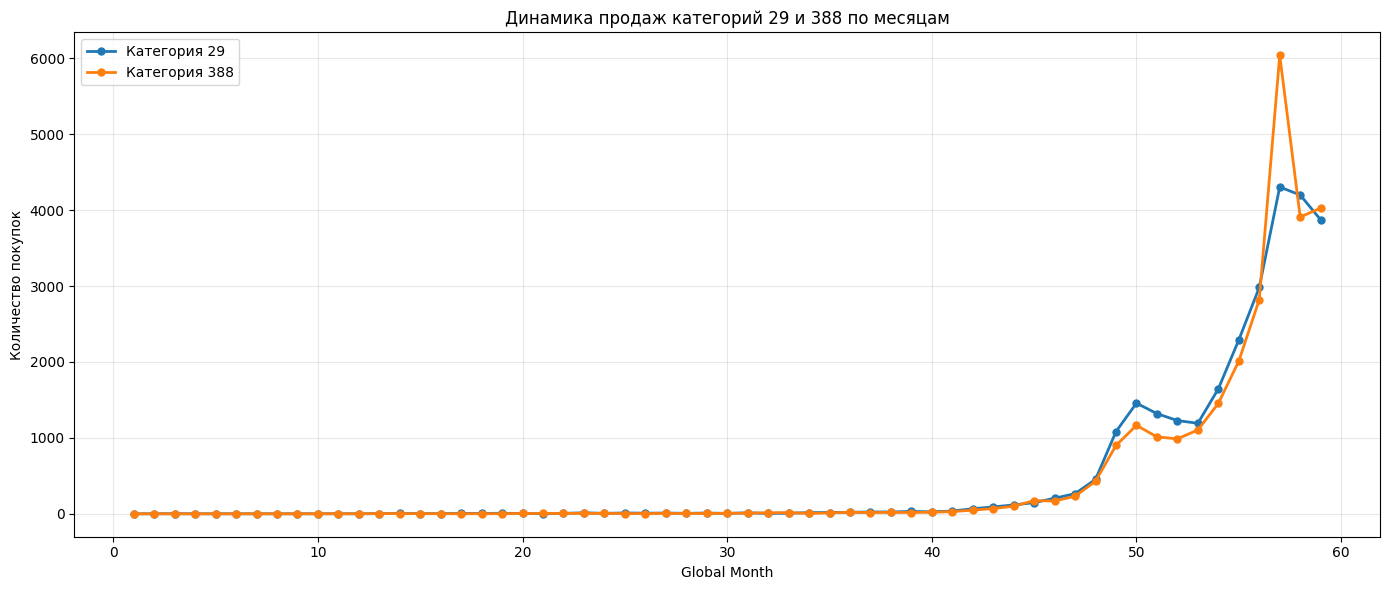

In [ ]:
# --- Визуализация ---
# 1. Динамика продаж (count)
plt.figure(figsize=(14, 6))
pivot_counts = df_filtered.pivot_table(index='global_month', columns='category', values='count', fill_value=0)
# Убедимся, что все месяцы присутствуют
all_months = range(1, last_full_month + 1)
pivot_counts = pivot_counts.reindex(all_months, fill_value=0)

for cat in categories_of_interest:
    if cat in pivot_counts.columns:
        plt.plot(pivot_counts.index, pivot_counts[cat], marker='o', linewidth=2, markersize=5, label=f'Категория {cat}')

plt.title('Динамика продаж категорий 29 и 388 по месяцам')
plt.xlabel('Global Month')
plt.ylabel('Количество покупок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



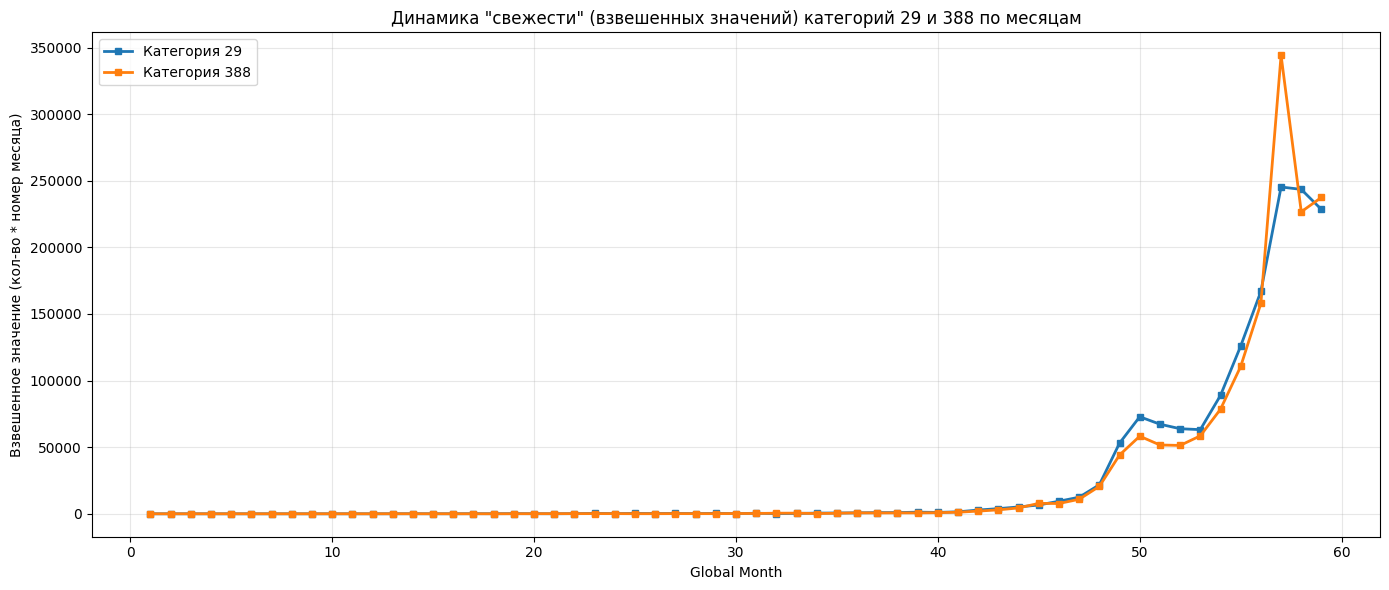

In [ ]:
# 2. Динамика "свежести" (weighted_count)
plt.figure(figsize=(14, 6))
pivot_weighted = df_filtered.pivot_table(index='global_month', columns='category', values='weighted_count', fill_value=0)
pivot_weighted = pivot_weighted.reindex(all_months, fill_value=0)

for cat in categories_of_interest:
    if cat in pivot_weighted.columns:
        plt.plot(pivot_weighted.index, pivot_weighted[cat], marker='s', linewidth=2, markersize=5, label=f'Категория {cat}')

plt.title('Динамика "свежести" (взвешенных значений) категорий 29 и 388 по месяцам')
plt.xlabel('Global Month')
plt.ylabel('Взвешенное значение (кол-во * номер месяца)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Вывод ---
print("\n" + "="*50)
print("Вывод:")
cat_29_freshness = freshness_scores[29]
cat_388_freshness = freshness_scores[388]

print(f"Категория 29: Общие продажи = {total_counts[29]}, "
      f"Свежесть в месяце {last_full_month} = {cat_29_freshness}")
print(f"Категория 388: Общие продажи = {total_counts[388]}, "
      f"Свежесть в месяце {last_full_month} = {cat_388_freshness}")

if cat_29_freshness > cat_388_freshness:
    print(f"Категория 29 более 'свежая' в последнем месяце ({last_full_month}).")
elif cat_29_freshness < cat_388_freshness:
    print(f"Категория 388 более 'свежая' в последнем месяце ({last_full_month}).")
else:
    print(f"Категории 29 и 388 имеют одинаковую 'свежесть' в последнем месяце ({last_full_month}).")


Вывод:
Категория 29: Общие продажи = 27244, Свежесть в месяце 59 = 228448
Категория 388: Общие продажи = 26890, Свежесть в месяце 59 = 237534
Категория 388 более 'свежая' в последнем месяце (59).


Вывод
Анализ "свежести" подтверждает наблюдение из сравнения топов: категория 388, хотя и может отставать по общему объему продаж, набирает обороты в последний анализируемый период, особенно среди стабильных пользователей. Это позволяет предположить обратную причинно-следственную связь: не просто стабильные пользователи отражают тренд, но их устойчивый интерес к категории (в данном случае 388) способствует тому, что эта категория воспринимается как более "свежая" или актуальная в последние месяцы. Таким образом, поведение стабильных пользователей можно рассматривать как индикатор формирования или укрепления тренда, а не только как его отражение.